# Capa Bronce

##  Lectura de Datos

In [1]:
import pandas as pd
data = pd.read_csv('data/iris.csv')
data = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']]
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Integridad de datos

### Resumen General

In [2]:
import pandas as pd
import numpy as np

def resumen_variables(df, top_categorias=10):
    """
    Genera un resumen de las variables de un DataFrame.

    Parámetros:
    ----------
    df : pandas.DataFrame
        Dataset a analizar.
    top_categorias : int
        Número máximo de categorías a mostrar para variables categóricas.
    Retorna:
    -------
    resumen_df : pandas.DataFrame
        Resumen general de variables.
    categorias_dict : dict
        Conteos de categorías por variable categórica.
    """
    resumen = []
    categorias_dict = {}
    for col in df.columns:
        # Tipo de dato
        tipo = str(df[col].dtype)
        # Cantidad de missings
        n_missing = df[col].isnull().sum()
        pct_missing = round((n_missing / len(df)) * 100, 2)
        # Cantidad de valores únicos
        n_unicos = df[col].nunique(dropna=True)
        # Identificar si es numérica
        es_numerica = pd.api.types.is_numeric_dtype(df[col])
        # Estadísticas para numéricas
        if es_numerica:
            media = df[col].mean()
            minimo = df[col].min()
            maximo = df[col].max()
            resumen.append({
                "Variable": col,
                "Tipo": tipo,
                "Es_Numerica": True,
                "Missings": n_missing,
                "%_Missings": pct_missing,
                "Valores_Unicos": n_unicos,
                "Media": media,
                "Min": minimo,
                "Max": maximo
            })
        else:
            # Conteo de categorías
            conteo = (
                df[col]
                .value_counts(dropna=False)
                .head(top_categorias)
                .reset_index()
            )
            conteo.columns = ["Categoria", "Conteo"]
            categorias_dict[col] = conteo
            resumen.append({
                "Variable": col,
                "Tipo": tipo,
                "Es_Numerica": False,
                "Missings": n_missing,
                "%_Missings": pct_missing,
                "Valores_Unicos": n_unicos,
                "Media": np.nan,
                "Min": np.nan,
                "Max": np.nan
            })
    resumen_df = pd.DataFrame(resumen)
    return resumen_df, categorias_dict

In [3]:
resumen_variables(data)[0]

,Variable,Tipo,Es_Numerica,Missings,%_Missings,Valores_Unicos,Media,Min,Max
0,SepalLengthCm,float64,True,0,0.0,35,5.843333,4.3,7.9
1,SepalWidthCm,float64,True,0,0.0,23,3.054000,2.0,4.4
2,PetalLengthCm,float64,True,0,0.0,43,3.758667,1.0,6.9
3,PetalWidthCm,float64,True,0,0.0,22,1.198667,0.1,2.5
4,Species,object,False,0,0.0,3,NaN,NaN,NaN


In [4]:
resumen_variables(data)[1]

{'Species':          Categoria  Conteo
 0      Iris-setosa      50
 1  Iris-versicolor      50
 2   Iris-virginica      50}

## Missings

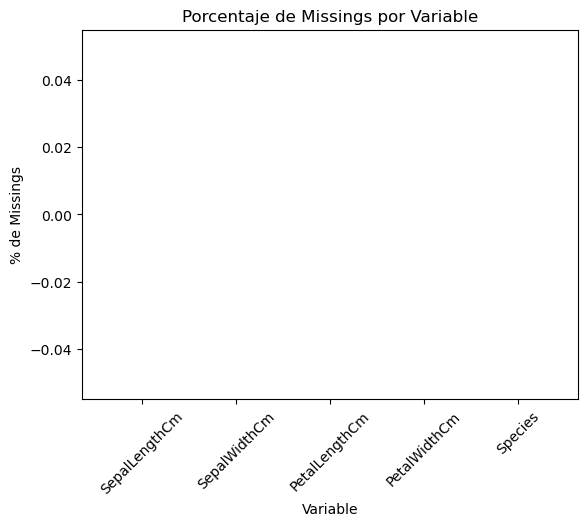

In [5]:
import matplotlib.pyplot as plt
plt.bar(resumen_variables(data)[0]['Variable'], resumen_variables(data)[0]['%_Missings'])
plt.xlabel('Variable')
plt.ylabel('% de Missings')
plt.title('Porcentaje de Missings por Variable')
plt.xticks(rotation=45)
plt.show()

## Duplicados

In [6]:
import pandas as pd

def contar_duplicados(df):
    """
    Cuenta la cantidad de registros duplicados en un DataFrame.
    Parámetros:
    -----------
    df : pandas.DataFrame
    Retorna:
    --------
    int
        Número de filas duplicadas.
    """
    return df.duplicated().sum()

In [7]:
contar_duplicados(data)

np.int64(3)

# Tratamiento de Datos Capa Plata

## Eliminación de Duplicados

In [11]:
data_silver = data.drop_duplicates(subset=None,
                               keep='first',
                               inplace=False
)
data_silver.head(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [12]:
contar_duplicados(data_silver)

np.int64(0)

# Almacenamiento de Capa Plata

In [14]:
data_silver.to_csv('data/iris_silver.csv', index=False)